In [5]:
# Importing the required packages
import calliope
import pandas as pd
from spores_algorithm import run_spores
from plotting_utilities import plot_dispatch, plot_capacity, plot_network
import matplotlib.pyplot as plt

import glob
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances_argmin_min
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist
import matplotlib.dates as mdates
import numpy as np
import xarray as xr

# Setting the verbosity level for Calliope
calliope.set_log_verbosity('INFO', include_solver_output=False) # Defines how much information you get 
                                                               #from the machine as the model gets built and run

Loads all SPORE NetCDF result files, extracts and aggregates the variable `cost_operation_variable` by timestep for each SPORE, and constructs a matrix where each row is a SPORE and each column is a timestep.

In [6]:
# List all the SPORE files (adjust path pattern as needed)
spore_files = glob.glob('results/spores/*.nc')  # Adjust this if needed

# Initialize an empty list to hold the aggregated data for each SPORE
aggregated_data_list = []

# Iterate over each SPORE file
for file in spore_files:
    # Open the NetCDF file
    data = xr.open_dataset(file)
    
    # Convert source capacities to DataFrame
    data_df = data['capacity_factor'].to_dataframe().reset_index()
    data_df = data_df[~data_df['techs'].str.contains(r'_to_', regex=True)]
    data_df['capacity_factor'] = data_df['capacity_factor'] / 3
    data_df = data_df.dropna(subset=['capacity_factor']) 
    
    # Aggregate the source capacities by tech
    aggregated_flow_cap = data_df.groupby('timesteps')['capacity_factor'].mean().reset_index()
    
    # Convert the aggregated source capacities into a series with tech as the index
    aggregated_series = aggregated_flow_cap.set_index('timesteps')['capacity_factor']
    
    spore_name = file.split('/')[-1].split('.')[0]  # Extracting 'maxnuc_spore_1' from the file name
    aggregated_series.name = spore_name  # Name the row by the SPORE name

    # Append the aggregated data (this will form the rows in the final matrix)
    aggregated_data_list.append(aggregated_series)

# Combine all SPORE aggregated data into a single DataFrame (with each SPORE as a row)
aggregated_matrix = pd.concat(aggregated_data_list, axis=1).T

# Set the column names to be the techs
aggregated_matrix.columns = aggregated_flow_cap['timesteps']

# Show the resulting matrix
aggregated_matrix


timesteps,2019-01-01 00:00:00,2019-01-01 03:00:00,2019-01-01 06:00:00,2019-01-01 09:00:00,2019-01-01 12:00:00,2019-01-01 15:00:00,2019-01-01 18:00:00,2019-01-01 21:00:00,2019-01-02 00:00:00,2019-01-02 03:00:00,...,2019-12-30 18:00:00,2019-12-30 21:00:00,2019-12-31 00:00:00,2019-12-31 03:00:00,2019-12-31 06:00:00,2019-12-31 09:00:00,2019-12-31 12:00:00,2019-12-31 15:00:00,2019-12-31 18:00:00,2019-12-31 21:00:00
spore_5,0.297634,0.302458,0.303597,0.307428,0.309863,0.312098,0.315986,0.314961,0.314010,0.308621,...,0.311135,0.283673,0.277523,0.274115,0.289522,0.277920,0.276243,0.290569,0.294964,0.291759
minons_spore_8,0.318059,0.322127,0.323442,0.326610,0.328899,0.332555,0.335552,0.333968,0.332811,0.327726,...,0.322816,0.304087,0.298929,0.295112,0.305347,0.299539,0.297442,0.306126,0.304352,0.302007
minoff_spore_7,0.313847,0.317956,0.319202,0.317755,0.320051,0.328276,0.331433,0.329932,0.328796,0.323686,...,0.309186,0.299950,0.294847,0.291067,0.297808,0.286571,0.293709,0.298472,0.298393,0.295384
maxpv_spore_3,0.225931,0.230748,0.232380,0.235862,0.238297,0.241438,0.244672,0.243402,0.243090,0.241282,...,0.293003,0.271668,0.257992,0.265715,0.295702,0.254157,0.251443,0.297881,0.296642,0.294920
maxbat_spore_3,0.216863,0.222051,0.223935,0.228095,0.231912,0.230698,0.235337,0.234621,0.234263,0.230582,...,0.256956,0.206931,0.201601,0.213398,0.323884,0.216466,0.216274,0.326987,0.289445,0.245989
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
minpv_spore_4,0.317117,0.320943,0.321522,0.318025,0.319849,0.330904,0.334469,0.332855,0.331592,0.326040,...,0.320224,0.302766,0.297410,0.293387,0.302311,0.291873,0.291436,0.304222,0.301661,0.300086
maxoff_spore_5,0.232827,0.237295,0.238821,0.242882,0.245193,0.247703,0.251284,0.250021,0.249029,0.243667,...,0.252084,0.238491,0.219783,0.243123,0.294572,0.253565,0.252008,0.298677,0.295268,0.264971
minbat_spore_1,0.231972,0.236185,0.237926,0.240388,0.244351,0.245215,0.249076,0.247287,0.246432,0.244319,...,0.242532,0.227762,0.222205,0.229162,0.263046,0.232946,0.231470,0.266185,0.258468,0.233893
maxbio_spore_10,0.220617,0.224232,0.225494,0.227523,0.229984,0.234708,0.237817,0.235540,0.233793,0.229863,...,0.217104,0.207345,0.202085,0.199024,0.201714,0.204908,0.211094,0.272582,0.208110,0.195124


Standardizes the aggregated matrix data using `StandardScaler` to prepare for clustering.

In [7]:
# Standardize the data
scaler = StandardScaler()
matrix_scaled = scaler.fit_transform(aggregated_matrix)  # Normalize across all technologies

In [8]:
import numpy as np
from sklearn.metrics import pairwise_distances

def hopkins_statistic(X):
    """
    Calculate the Hopkins statistic for a dataset X.
    Parameters:
    X: ndarray, shape (n_samples, n_features)
       The dataset to calculate the Hopkins statistic for.
       
    Returns:
    H: float
       The Hopkins statistic value.
    """
    # Number of data points to sample
    n = X.shape[0]
    
    # Step 1: Select a random subset of data points
    random_data = np.random.rand(n, X.shape[1])  # Generate random data points in the same space
    
    # Step 2: Calculate the pairwise distances for real data and random data
    dist_real = pairwise_distances(X, X)
    dist_random = pairwise_distances(X, random_data)
    
    # Step 3: For each point in the dataset, find the minimum distance to its nearest neighbor
    min_real_distances = np.min(dist_real, axis=1)
    min_random_distances = np.min(dist_random, axis=1)
    
    # Step 4: Compute the Hopkins statistic
    H = np.sum(min_real_distances) / (np.sum(min_real_distances) + np.sum(min_random_distances))
    
    return H

# Assuming `aggregated_matrix` is your DataFrame with SPORE configurations as rows and features (e.g., technology capacities) as columns

# Convert the aggregated matrix to a NumPy array (each row represents a SPORE configuration)
data = aggregated_matrix.values

# Calculate the Hopkins statistic for the dataset
H = hopkins_statistic(data)

# Print the Hopkins statistic value
print(f"Hopkins Statistic: {H}")


Hopkins Statistic: 0.0


Applies DBSCAN clustering to the standardized data and prints the number of clusters found.

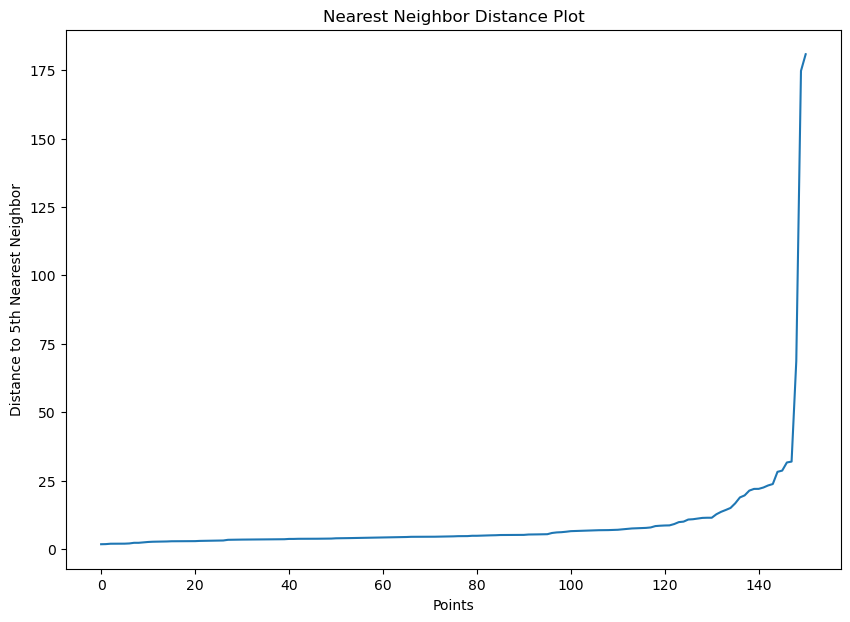

In [9]:
from sklearn.neighbors import NearestNeighbors

# Calculate the nearest neighbor distances
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(matrix_scaled)
distances, indices = neighbors_fit.kneighbors(matrix_scaled)

# Sort the distances in ascending order
distances = np.sort(distances[:,4], axis=0)

# Plot the distances
plt.figure(figsize=(10, 7))
plt.plot(distances)
plt.title('Nearest Neighbor Distance Plot')
plt.xlabel('Points')
plt.ylabel('Distance to 5th Nearest Neighbor')
plt.show()


In [18]:
# Apply DBSCAN with eps=0.5 and min_samples=5
db = DBSCAN(eps=23, min_samples=10)
db_labels = db.fit_predict(matrix_scaled)

# Check the number of distinct clusters
print(f"Number of clusters found by DBSCAN: {len(set(db_labels)) - (1 if -1 in db_labels else 0)}")

Number of clusters found by DBSCAN: 4


In [19]:
from sklearn.cluster import DBSCAN

# eps: The maximum distance between two points for them to be considered as part of the same neighborhood. 
# min_samples: The number of points required to form a dense region (a cluster).
dbscan = DBSCAN(eps=23, min_samples=10)

cluster_labels = dbscan.fit_predict(matrix_scaled)

# Add the DBSCAN cluster labels to the aggregated_matrix
aggregated_matrix['Cluster_DBSCAN'] = cluster_labels


In [20]:
# Check the number of points in each cluster
print(aggregated_matrix['Cluster_DBSCAN'].value_counts())

Cluster_DBSCAN
 0    66
 2    47
-1    18
 1    10
 3    10
Name: count, dtype: int64


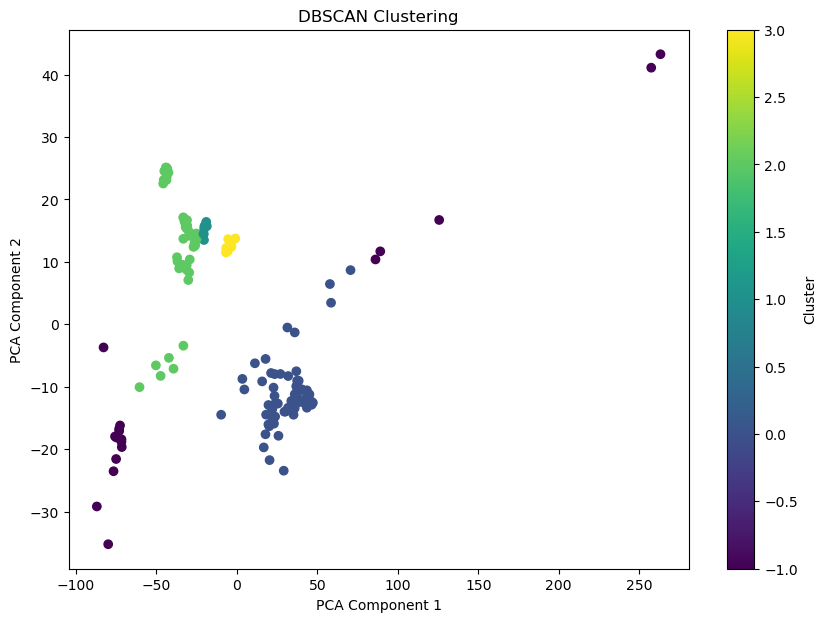

In [21]:
from sklearn.decomposition import PCA

# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
pca_result = pca.fit_transform(matrix_scaled)

# Plot the DBSCAN clusters in 2D
plt.figure(figsize=(10, 7))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=aggregated_matrix['Cluster_DBSCAN'], cmap='viridis')
plt.title('DBSCAN Clustering')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.show()


In [22]:
from sklearn.metrics import davies_bouldin_score

db_score = davies_bouldin_score(matrix_scaled, cluster_labels)
print(f"Davies-Bouldin score: {db_score:.3f}")

from sklearn.metrics import calinski_harabasz_score

ch_score = calinski_harabasz_score(matrix_scaled, cluster_labels)
print(f"Calinski-Harabasz score: {ch_score:.3f}")

from sklearn.metrics import silhouette_score
score = silhouette_score(matrix_scaled, cluster_labels)
print(f'Silhouette score: {score:.3f}')

Davies-Bouldin score: 3.331
Calinski-Harabasz score: 20.542
Silhouette score: 0.426


In [23]:
metrics_summary = {
    'Davies-Bouldin': db_score,
    'Calinski-Harabasz': ch_score,
    'Silhouette': score
}
metrics_summary = pd.DataFrame({
    'score': ['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz'],
    'value': [score, db_score, ch_score]
})

Extracts a general SPORE category from each configuration, groups by cluster and category, and counts the occurrences in a summary table.

In [25]:
# Dynamically extract the general SPORE category from the 'techs' index by splitting the names
aggregated_matrix_count = aggregated_matrix.copy()

aggregated_matrix_count['spore_category_general'] = aggregated_matrix_count.index.to_series().apply(lambda x: x.split('_spore')[0])

# Now, group by 'Cluster' and 'spore_category_general' and count the occurrences
cluster_spore_count = aggregated_matrix_count.groupby(['Cluster_DBSCAN', 'spore_category_general']).size().unstack(fill_value=0)

# Show the resulting table
cluster_spore_count['spore_main'] = cluster_spore_count[['spore_1', 'spore_2', 'spore_3', 'spore_4', 'spore_5', 'spore_6', 'spore_7', 'spore_8', 'spore_9', 'spore_10']].sum(axis=1)
cluster_spore_count = cluster_spore_count.drop(columns=['spore_1', 'spore_2', 'spore_3', 'spore_4', 'spore_5', 'spore_6', 'spore_7', 'spore_8', 'spore_9', 'spore_10'])

cluster_spore_count

spore_category_general,maxbat,maxbio,maxhtp,maxnuc,maxoff,maxons,maxpv,minbat,minbio,minhtp,minnuc,minoff,minons,minpv,spore_baseline,spore_main
Cluster_DBSCAN,,,,,,,,,,,,,,,,
-1,0,10,0,0,0,0,0,0,5,0,0,0,0,0,0,3
0,0,0,0,0,0,0,0,9,5,9,9,9,9,9,0,7
1,0,0,0,0,0,0,10,0,0,0,0,0,0,0,0,0
2,10,0,10,0,10,10,0,1,0,1,1,1,1,1,1,0
3,0,0,0,10,0,0,0,0,0,0,0,0,0,0,0,0


In [26]:
# remove the noise data points
aggregated_matrix = aggregated_matrix[aggregated_matrix['Cluster_DBSCAN'] != -1]

Calculates and displays the mean value for each technology in each cluster.

In [27]:
# Group by 'Cluster' and calculate the mean for each technology
cluster_summary = aggregated_matrix.groupby('Cluster_DBSCAN').mean()

# Show the resulting cluster summary
cluster_summary


timesteps,2019-01-01 00:00:00,2019-01-01 03:00:00,2019-01-01 06:00:00,2019-01-01 09:00:00,2019-01-01 12:00:00,2019-01-01 15:00:00,2019-01-01 18:00:00,2019-01-01 21:00:00,2019-01-02 00:00:00,2019-01-02 03:00:00,...,2019-12-30 18:00:00,2019-12-30 21:00:00,2019-12-31 00:00:00,2019-12-31 03:00:00,2019-12-31 06:00:00,2019-12-31 09:00:00,2019-12-31 12:00:00,2019-12-31 15:00:00,2019-12-31 18:00:00,2019-12-31 21:00:00
Cluster_DBSCAN,,,,,,,,,,,,,,,,,,,,,
0,0.305931,0.309719,0.311411,0.313827,0.315853,0.319826,0.323005,0.321474,0.320245,0.315544,...,0.310802,0.293406,0.287943,0.285102,0.297104,0.288767,0.286875,0.298438,0.298296,0.293450
1,0.225386,0.230247,0.231873,0.235431,0.237848,0.240930,0.244171,0.242951,0.242667,0.240870,...,0.293216,0.270715,0.256876,0.264928,0.296889,0.253858,0.249502,0.302514,0.302075,0.295701
2,0.229384,0.233851,0.235403,0.239011,0.241673,0.243898,0.247423,0.246152,0.245251,0.240492,...,0.247528,0.223942,0.218876,0.234144,0.296164,0.243913,0.242885,0.300130,0.288862,0.261026
3,0.259362,0.263494,0.264887,0.268326,0.270698,0.273823,0.276999,0.275539,0.274471,0.269410,...,0.284745,0.247402,0.241247,0.249869,0.308113,0.254534,0.252478,0.310090,0.309206,0.275663


Plots the centroid values (mean per cluster) over time for each cluster.

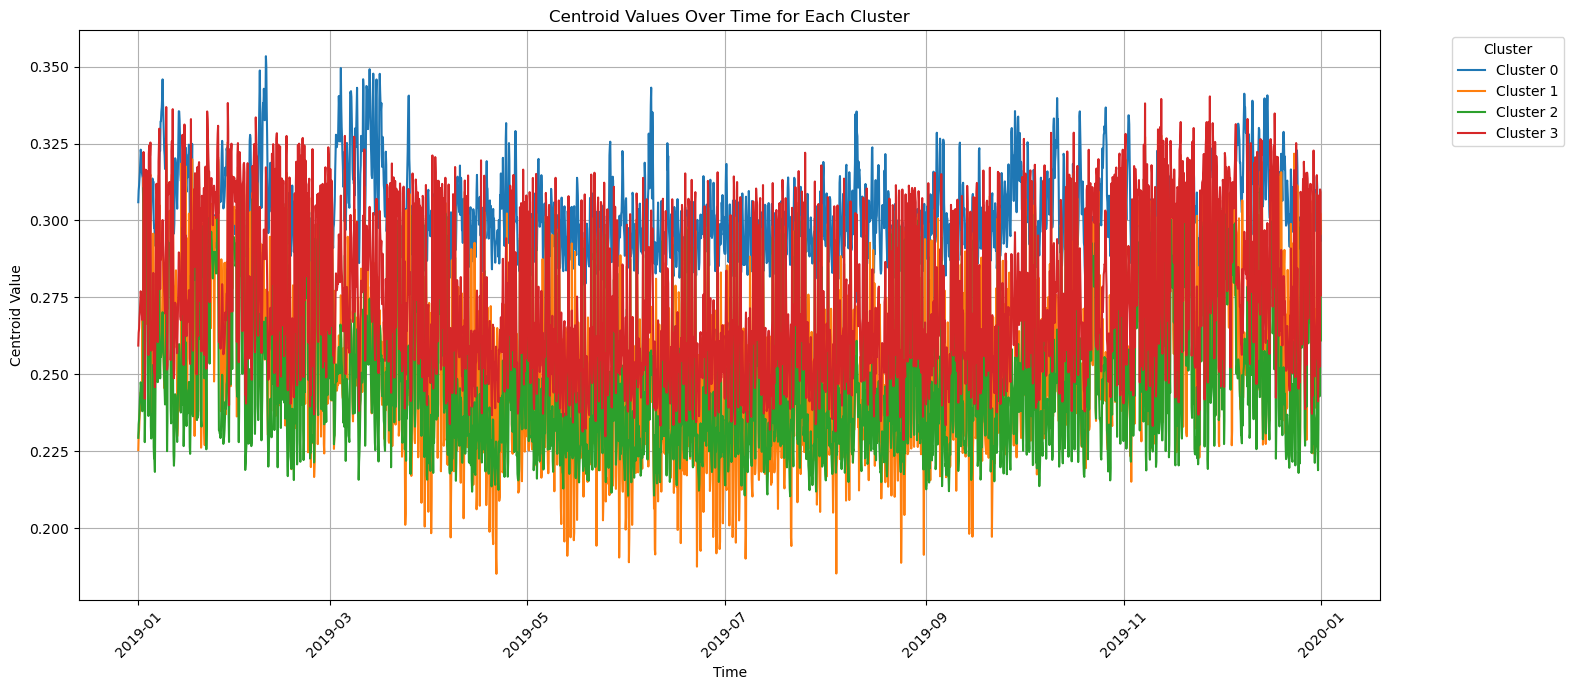

In [28]:
# Let's plot the data (one line for each cluster)
plt.figure(figsize=(14, 7))

# Loop through each cluster (row) and plot its centroid values over time (columns)
for cluster in cluster_summary.index:
    plt.plot(cluster_summary.columns, cluster_summary.loc[cluster], label=f'Cluster {cluster}')

# Add titles and labels
plt.title('Centroid Values Over Time for Each Cluster')
plt.xlabel('Time')
plt.ylabel('Centroid Value')
plt.xticks(rotation=45)  # Rotate time labels for better readability
plt.grid(True)
plt.tight_layout()
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

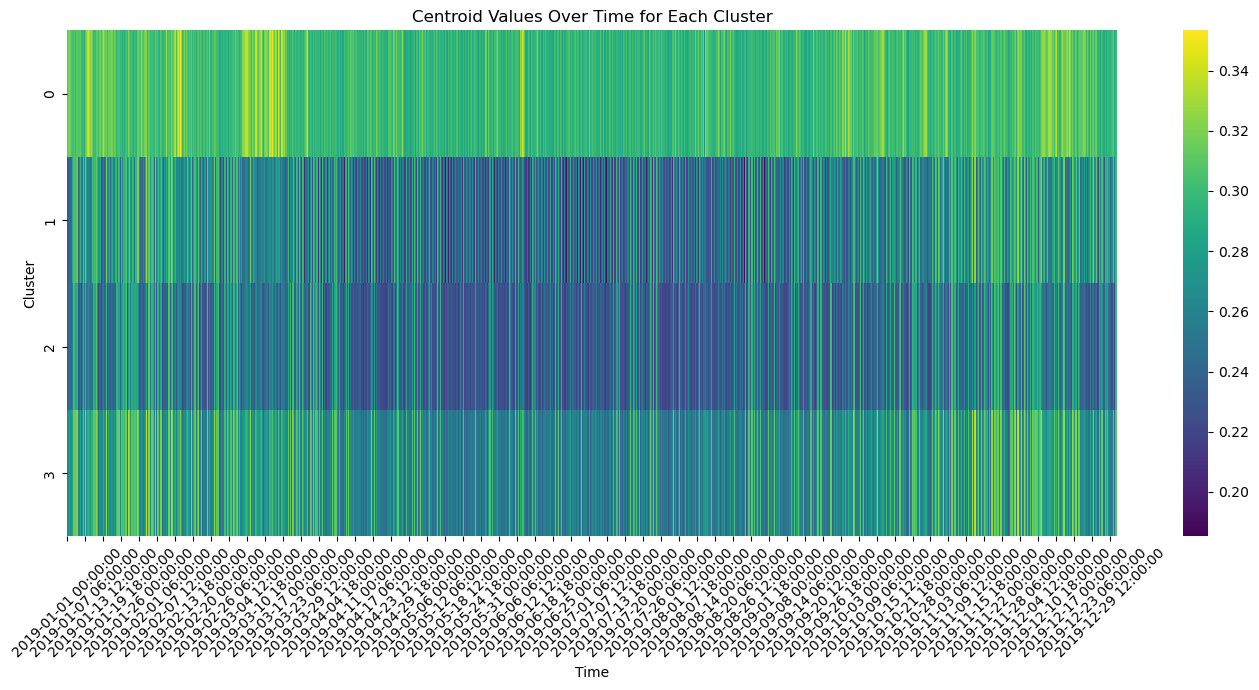

In [29]:
import seaborn as sns

# You can plot a heatmap to visualize the matrix more effectively
plt.figure(figsize=(14, 7))
sns.heatmap(cluster_summary, cmap='viridis', xticklabels=50, yticklabels=True)  # Adjust xticklabels and yticklabels
plt.title('Centroid Values Over Time for Each Cluster')
plt.xlabel('Time')
plt.ylabel('Cluster')
plt.xticks(rotation=45)  # Rotate time labels for better readability
plt.tight_layout()
plt.show()


In [30]:
import plotly.express as px

# Convert to DataFrame if not already
cluster_df = cluster_summary.T  # Transpose to have time as index

# Plot interactive line plot with Plotly
fig = px.line(cluster_df, title="Centroid Values Over Time for Each Cluster", labels={'index': 'Time', 'value': 'Centroid Value'})
fig.show()


[2025-06-06 01:40:21] WARNING  /Users/lucazerotre/miniforge3/envs/calliope_NL/lib/python3.12/site-packages/narwhals/_pandas_like/series.py:202: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Series constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return cls.from_native(ns.Series(data, name=name, **kwds), context=context)



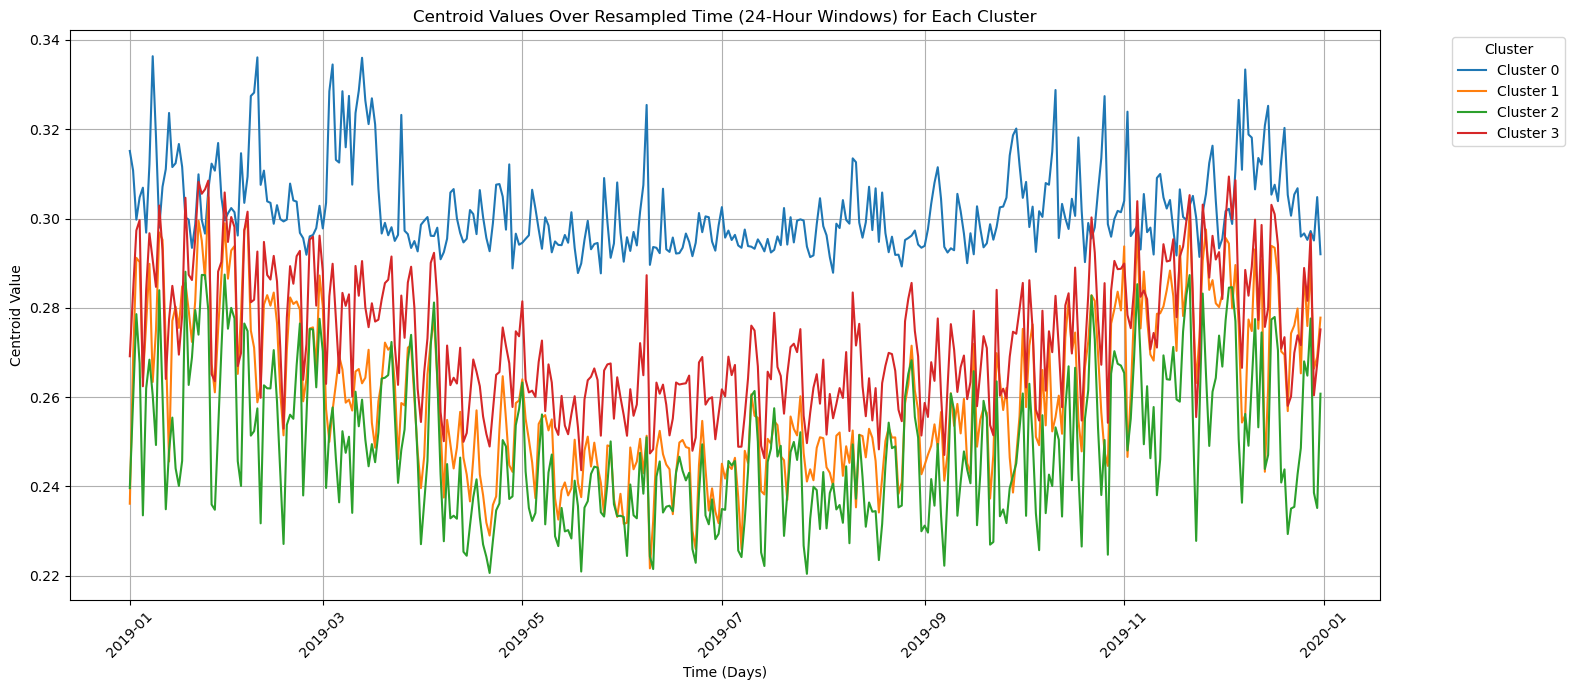

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure that the timesteps (columns) are in datetime format
cluster_summary.columns = pd.to_datetime(cluster_summary.columns)

# Convert the rows (clusters) into columns for easier processing
cluster_summary_T = cluster_summary.T  # Transpose to make timesteps the rows

# Now resample the data by averaging over every 24-hour period (group by day)
cluster_resampled = cluster_summary_T.resample('D').mean()

# Plot the resampled centroid values over time
plt.figure(figsize=(14, 7))

# Loop through each cluster (row) and plot its centroid values over the resampled time
for cluster in cluster_resampled.columns:
    plt.plot(cluster_resampled.index, cluster_resampled[cluster], label=f'Cluster {cluster}')

# Add titles and labels
plt.title('Centroid Values Over Resampled Time (24-Hour Windows) for Each Cluster')
plt.xlabel('Time (Days)')
plt.ylabel('Centroid Value')
plt.xticks(rotation=45)  # Rotate time labels for better readability
plt.grid(True)
plt.tight_layout()
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


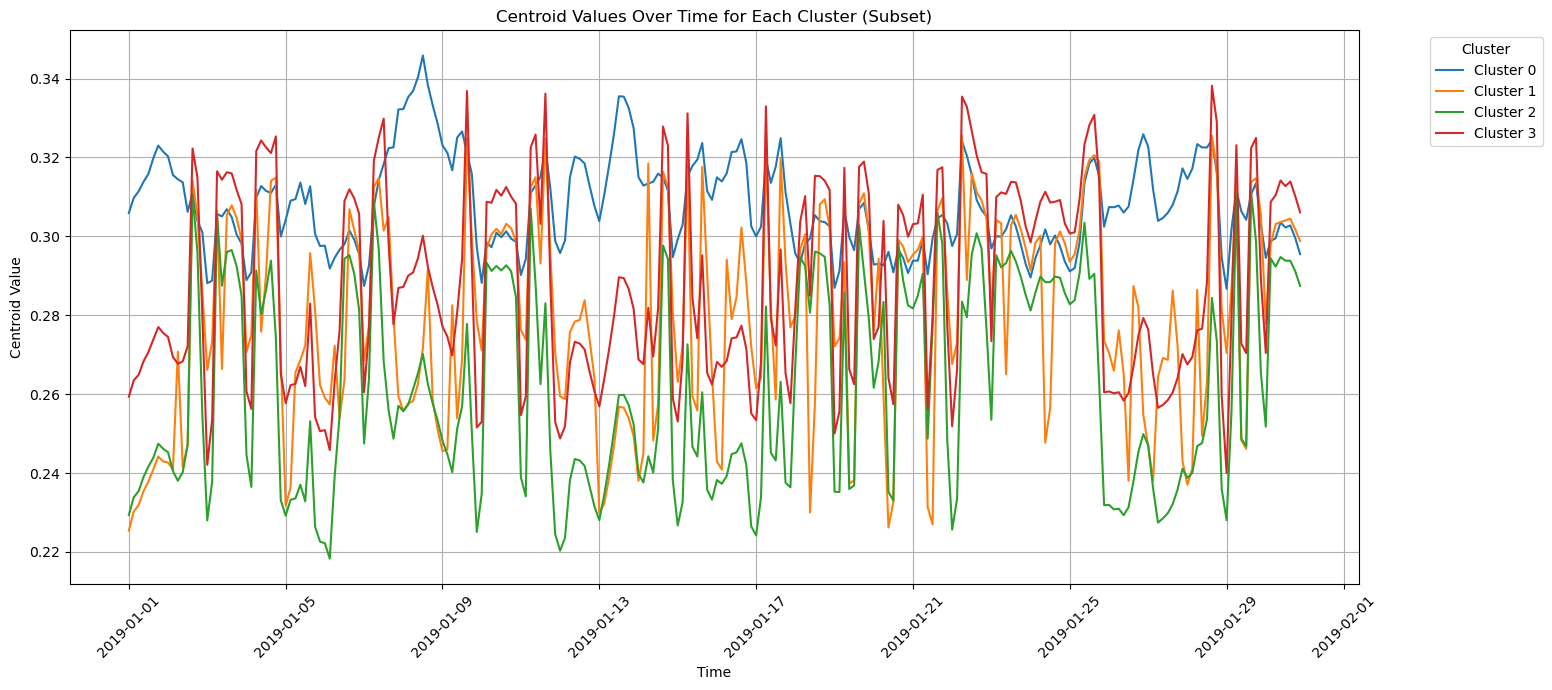

In [32]:
first_month = (int(input("Enter the first month to plot (1-12): "))-1)*240
last_month = (int(input("Enter the last month to plot (1-12): "))-1)*240
# Define the time range of interest based on user input
time_subset = cluster_summary.columns[first_month:last_month]  # Adjust as necessary
# Subset the data
cluster_subset = cluster_summary[time_subset]

# Plot the data (one line for each cluster)
plt.figure(figsize=(14, 7))

# Loop through each cluster (row) and plot its centroid values over the subset of time
for cluster in cluster_subset.index:
    plt.plot(cluster_subset.columns, cluster_subset.loc[cluster], label=f'Cluster {cluster}')

# Add titles and labels
plt.title('Centroid Values Over Time for Each Cluster (Subset)')
plt.xlabel('Time')
plt.ylabel('Centroid Value')
plt.xticks(rotation=45)  # Rotate time labels for better readability
plt.grid(True)
plt.tight_layout()
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


Finds the configuration closest to the centroid for each cluster (representative configuration) and plots their time series.

Cluster 0 - Shape of cluster_configs: (66, 2920)
Cluster 1 - Shape of cluster_configs: (10, 2920)
Cluster 2 - Shape of cluster_configs: (47, 2920)
Cluster 3 - Shape of cluster_configs: (10, 2920)
Representative configurations: ['minbat_spore_7', 'maxpv_spore_7', 'maxhtp_spore_2', 'maxnuc_spore_9']


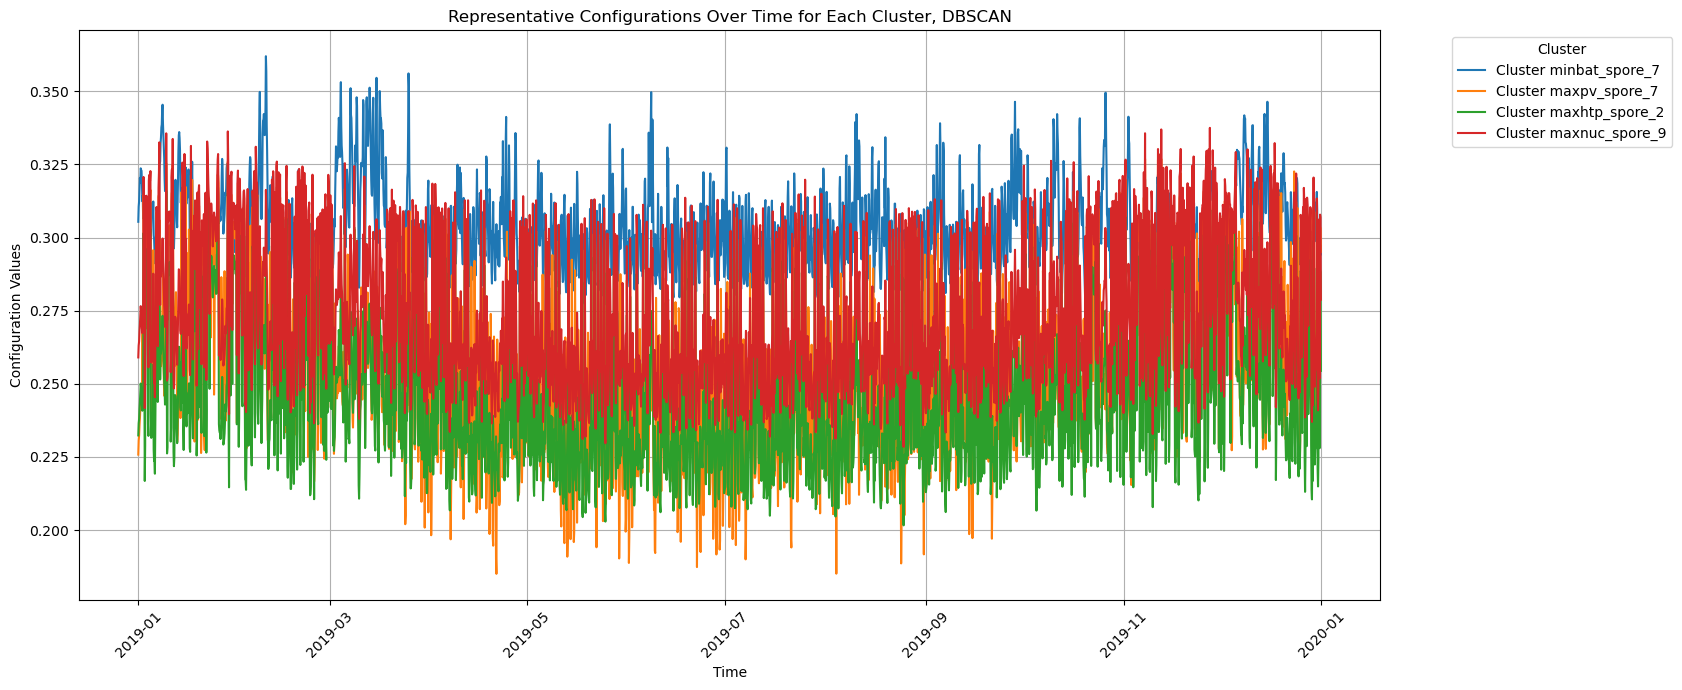

In [36]:
# 1. Compute the centroids of each cluster (mean of each technology in each cluster)
cluster_centroids = aggregated_matrix.groupby('Cluster_DBSCAN').mean()

# 2. Find the configuration closest to the centroid for each cluster
representative_configs = []

for cluster in aggregated_matrix['Cluster_DBSCAN'].unique():
    # Get the configurations in the current cluster
    cluster_configs = aggregated_matrix[aggregated_matrix['Cluster_DBSCAN'] == cluster].drop(columns=['Cluster_DBSCAN'])

    # Print the shape of the data to verify it's correct
    print(f"Cluster {cluster} - Shape of cluster_configs: {cluster_configs.shape}")

    # Calculate the centroid for the current cluster
    centroid = cluster_centroids.loc[cluster]

    # Compute the Euclidean distances between each configuration and the centroid
    distances = cdist(cluster_configs, centroid.values.reshape(1, -1), metric='euclidean')

    # Get the index of the closest configuration (minimum distance)
    closest_index = np.argmin(distances)
    representative_config = cluster_configs.iloc[closest_index].name

    # Append the representative configuration's index
    representative_configs.append(representative_config)

# Print the representative configurations' indices
print(f"Representative configurations: {representative_configs}")

# 3. Retrieve the representative configurations from the 'aggregated_matrix'
df_representative_configs = aggregated_matrix.loc[representative_configs].drop(columns=['Cluster_DBSCAN'])

plt.figure(figsize=(14, 7))

# Loop through each configuration in 'df_representative_configs' and plot the time series for each cluster
for config in df_representative_configs.index:
    # Extract the time series for the current configuration
    config_data = df_representative_configs.loc[config]
    
    # Plot the configuration over time
    plt.plot(df_representative_configs.columns, config_data, label=f'Cluster {config}')

# Customize the plot
plt.title('Representative Configurations Over Time for Each Cluster, DBSCAN')
plt.xlabel('Time')
plt.ylabel('Configuration Values')
plt.xticks(rotation=45)  # Rotate time labels for better readability
plt.grid(True)
plt.tight_layout()
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [37]:
first_month = (int(input("Enter the first month to plot (1-12): "))-1)*240
last_month = (int(input("Enter the last month to plot (1-12): "))-1)*240
# Define the time range of interest based on user input
time_subset = df_representative_configs.columns[first_month:last_month]  # Adjust as necessary
# Subset the data
cluster_subset = df_representative_configs[time_subset]

# Plot the data (one line for each cluster)
plt.figure(figsize=(14, 7))

# Loop through each cluster (row) and plot its centroid values over the subset of time
for cluster in cluster_subset.index:
    plt.plot(cluster_subset.columns, cluster_subset.loc[cluster], label=f'Cluster {cluster}')

# Add titles and labels
plt.title('Centroid Values Over Time for Each Cluster (Subset)')
plt.xlabel('Time')
plt.ylabel('Centroid Value')
plt.xticks(rotation=45)  # Rotate time labels for better readability
plt.grid(True)
plt.tight_layout()
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

ValueError: invalid literal for int() with base 10: ''

In [38]:
import plotly.express as px

# Convert to DataFrame if not already
cluster_df = df_representative_configs.T  # Transpose to have time as index

# Plot interactive line plot with Plotly
fig = px.line(cluster_df, title="Centroid Values Over Time for Each Cluster", labels={'index': 'Time', 'value': 'Centroid Value'})
fig.show()

[2025-06-06 01:42:15] WARNING  /Users/lucazerotre/miniforge3/envs/calliope_NL/lib/python3.12/site-packages/narwhals/_pandas_like/series.py:202: FutureWarning:

Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Series constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.




Computes various statistical metrics (max, min, mean, variance, percentiles, etc.) for each representative configuration and displays them in a table.

In [39]:
# 1. Compute the metrics for each configuration
metrics = {
    'max_value': df_representative_configs.max(axis=1),
    'min_value': df_representative_configs.min(axis=1),
    'mean_value': df_representative_configs.mean(axis=1),
    'variance_value': df_representative_configs.var(axis=1),
    'std_dev_value': df_representative_configs.std(axis=1),
    'range_value': df_representative_configs.max(axis=1) - df_representative_configs.min(axis=1),
    'percentile_25': df_representative_configs.quantile(0.25, axis=1),
    'percentile_50': df_representative_configs.quantile(0.5, axis=1),
    'percentile_75': df_representative_configs.quantile(0.75, axis=1),
}

# Convert the metrics to a DataFrame for easy visualization
metrics_df = pd.DataFrame(metrics)

metrics_df

,max_value,min_value,mean_value,variance_value,std_dev_value,range_value,percentile_25,percentile_50,percentile_75
minbat_spore_7,0.361993,0.259775,0.302407,0.000185,0.013604,0.102219,0.292719,0.299448,0.309510
maxpv_spore_7,0.328732,0.185037,0.260485,0.000928,0.030464,0.143695,0.234300,0.258565,0.286473
maxhtp_spore_2,0.318710,0.201611,0.247286,0.000756,0.027488,0.117098,0.226584,0.238286,0.266287
maxnuc_spore_9,0.337498,0.228435,0.272177,0.000614,0.024777,0.109063,0.253196,0.264443,0.292583


Performs linear regression on each representative configuration to calculate the slope (trend) over time and prints the slopes.

In [40]:
from scipy.stats import linregress

# 1. Perform linear regression for each representative configuration
# and calculate the slope of the regression line
slopes = []
for config in df_representative_configs.index:
    time = np.arange(len(df_representative_configs.columns))  # Time indices for each timestep
    y = df_representative_configs.loc[config].values
    slope, _, _, _, _ = linregress(time, y)
    slopes.append(slope)

slopes = pd.Series(slopes, index=df_representative_configs.index, name='Slope')
slopes_df = pd.DataFrame(slopes).reset_index()
slopes_df.columns = ['Representative Configuration', 'Slope']
print(f"Slopes of the linear regression for each representative configuration: {slopes}")

slopes_df = pd.DataFrame(slopes).reset_index()
slopes_df.columns = ['Representative Configuration', 'Slope']

Slopes of the linear regression for each representative configuration: minbat_spore_7   -1.175352e-06
maxpv_spore_7     1.247252e-06
maxhtp_spore_2   -3.001399e-07
maxnuc_spore_9   -3.408035e-07
Name: Slope, dtype: float64


Plots the representative configurations and overlays their linear regression trend lines for visual comparison.

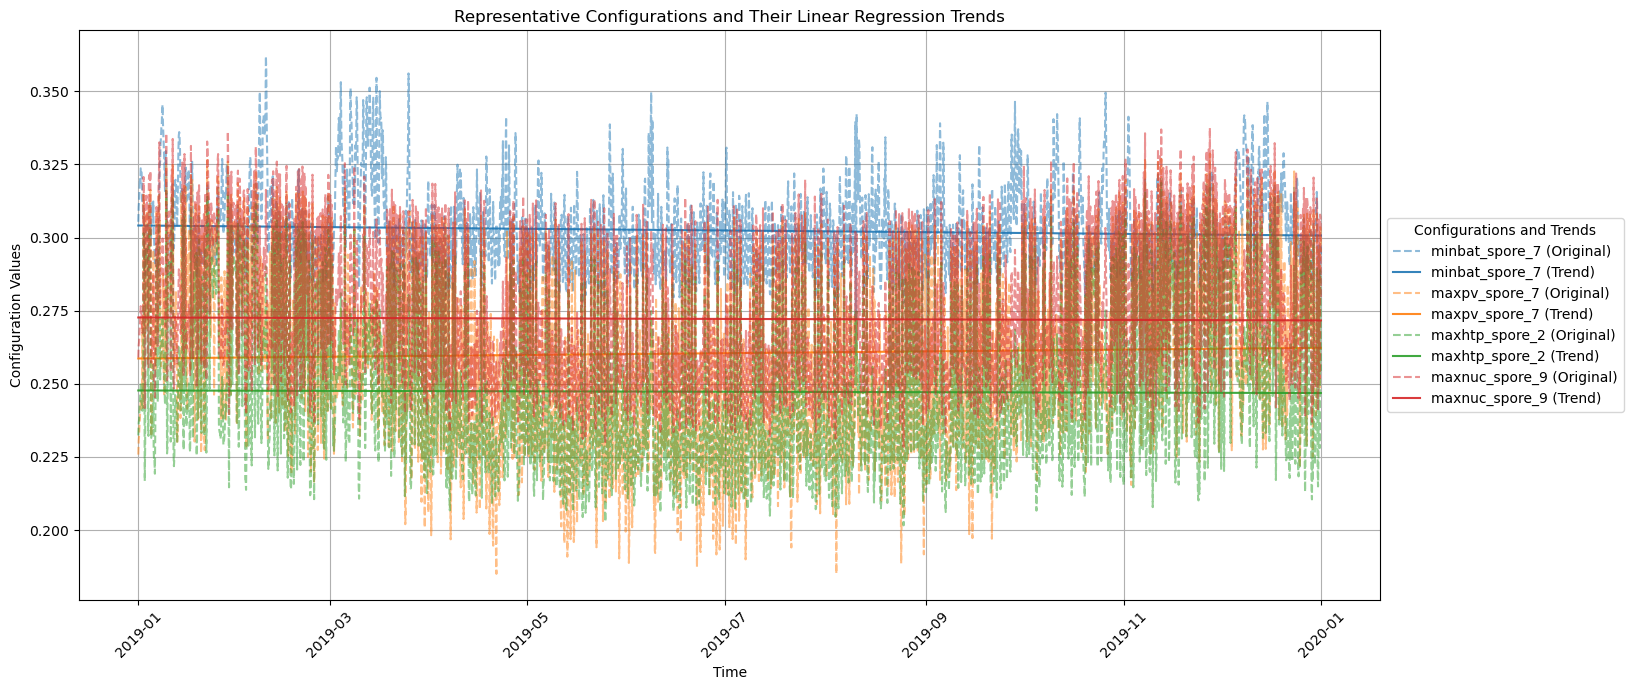

In [41]:
from scipy.stats import linregress
import matplotlib.cm as cm

# Plotting the representative configurations and their linear regression trends

# Initialize the plot
plt.figure(figsize=(14, 7))

# Loop through each representative configuration (row in df_representative_configs)
for i, config in enumerate(df_representative_configs.index):
    # Extract the time series for the current configuration
    config_data = df_representative_configs.loc[config]
    
    # Perform linear regression to get the slope and intercept
    time = np.arange(len(config_data))  # Time indices for each timestep
    slope, intercept, _, _, _ = linregress(time, config_data.values)
    
    # Generate the regression line (linear trend)
    regression_line = slope * time + intercept

    # Use a colormap to assign a unique color for each configuration
    base_color = cm.tab10(i % 10)
    
    # Plot the configuration over time
    plt.plot(df_representative_configs.columns, config_data, label=f'{config} (Original)', linestyle='--', color=base_color, alpha=0.5)
    
    # Plot the linear regression line
    trend_color = base_color
    plt.plot(df_representative_configs.columns, regression_line, label=f'{config} (Trend)', linestyle='-', color=trend_color, alpha=0.9)

# Customize the plot
plt.title('Representative Configurations and Their Linear Regression Trends')
plt.xlabel('Time')
plt.ylabel('Configuration Values')
plt.xticks(rotation=45)  # Rotate time labels for better readability
plt.grid(True)
plt.tight_layout()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='Configurations and Trends')
plt.show()


In [43]:
with pd.ExcelWriter('results/output_DBSCAN_time.xlsx', engine='openpyxl') as writer:
    cluster_spore_count.to_excel(writer, sheet_name='spore_count', index=True)
    cluster_summary.to_excel(writer, sheet_name='cluster_summary', index=True)
    df_representative_configs.to_excel(writer, sheet_name='representative_configs', index=True)
    metrics_summary.to_excel(writer, sheet_name='metrics_summary', index=False)
    metrics_df.to_excel(writer, sheet_name='statistics', index=True)
    slopes_df.to_excel(writer, sheet_name='slopes', index=False)